<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/lab11Neural_Network_Fundamentals_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

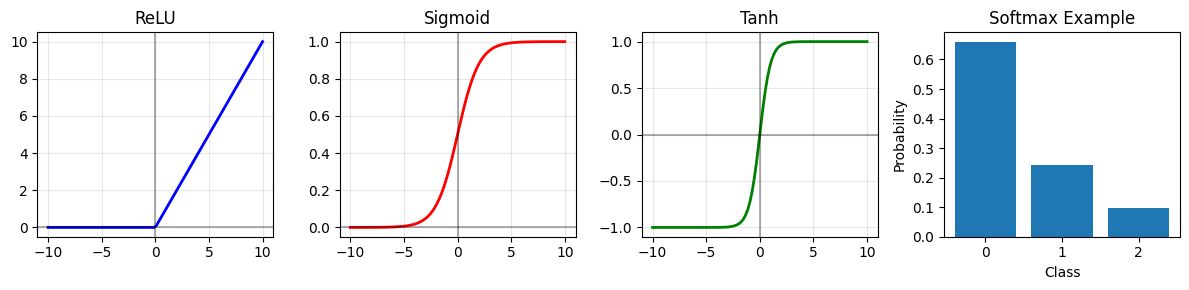

PART 1: SINGLE NEURON DEMONSTRATION
Input features: [1.5 2.  0.5]
Weights: [ 0.4 -0.2  0.9]
Bias: 0.1
Weighted sum (z): 0.7500
Output with ReLU: 0.7500
Output with Sigmoid: 0.6792


In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Activation Functions
def relu(z):
    """Rectified Linear Unit - outputs input if positive, else 0"""
    return np.maximum(0, z)

def sigmoid(z):
    """Sigmoid - squashes input to range (0, 1)"""
    return 1 / (1 + np.exp(-z))

def tanh(z):
    """Hyperbolic tangent - squashes input to range (-1, 1)"""
    return np.tanh(z)

def softmax(z):
    """Softmax - converts scores to probabilities summing to 1"""
    exp_z = np.exp(z - np.max(z))  # subtract max for numerical stability
    return exp_z / exp_z.sum()

# Visualize activation functions
z_values = np.linspace(-10, 10, 100)

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.plot(z_values, relu(z_values), 'b-', linewidth=2)
plt.title('ReLU')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.subplot(1, 4, 2)
plt.plot(z_values, sigmoid(z_values), 'r-', linewidth=2)
plt.title('Sigmoid')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.subplot(1, 4, 3)
plt.plot(z_values, tanh(z_values), 'g-', linewidth=2)
plt.title('Tanh')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.subplot(1, 4, 4)
# Show softmax for a few example inputs
example_scores = np.array([2.0, 1.0, 0.1])
probabilities = softmax(example_scores)
plt.bar(range(3), probabilities)
plt.title('Softmax Example')
plt.xlabel('Class')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

# Demonstrate a single neuron
print("=" * 50)
print("PART 1: SINGLE NEURON DEMONSTRATION")
print("=" * 50)

# A single neuron with 3 inputs
x = np.array([1.5, 2.0, 0.5])  # input features
w = np.array([0.4, -0.2, 0.9])  # weights
b = 0.1  # bias

z = np.dot(x, w) + b  # weighted sum + bias
output_relu = relu(z)  # apply ReLU activation
output_sigmoid = sigmoid(z)  # apply sigmoid activation

print(f"Input features: {x}")
print(f"Weights: {w}")
print(f"Bias: {b}")
print(f"Weighted sum (z): {z:.4f}")
print(f"Output with ReLU: {output_relu:.4f}")
print(f"Output with Sigmoid: {output_sigmoid:.4f}")

In [2]:
print("\n" + "=" * 50)
print("PART 2: MANUAL FORWARD PROPAGATION")
print("=" * 50)

# Load Wine dataset for real data
wine = load_wine()
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

print(f"Wine dataset shape: {X_wine.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {wine.target_names}")

# Use a real sample from the Wine dataset
sample_idx = 0
X = X_wine[sample_idx]  # 13 real features from wine sample
y_true = y_wine[sample_idx]

print(f"\nUsing wine sample {sample_idx}:")
print(f"Features: {X[:5]}... (showing first 5 of 13)")
print(f"True class: {wine.target_names[y_true]}")

# Manual Forward Propagation Through Two Layers
# Layer 1: Hidden layer with 4 neurons (ReLU activation)
# Layer 2: Output layer with 3 neurons (Softmax for multiclass)

np.random.seed(42)  # for reproducible results

# Network architecture: 13 inputs -> 4 hidden neurons -> 3 output neurons
input_size = 13
hidden_size = 4
output_size = 3

# Initialize weights and biases randomly
W1 = np.random.randn(input_size, hidden_size) * 0.1  # 13x4
b1 = np.zeros(hidden_size)  # 4
W2 = np.random.randn(hidden_size, output_size) * 0.1  # 4x3
b2 = np.zeros(output_size)  # 3

print(f"\nNetwork Architecture:")
print(f"Input layer: {input_size} neurons")
print(f"Hidden layer: {hidden_size} neurons (ReLU)")
print(f"Output layer: {output_size} neurons (Softmax)")

# Forward propagation
hidden_z = np.dot(X, W1) + b1
hidden_a = relu(hidden_z)  # hidden layer activations

output_z = np.dot(hidden_a, W2) + b2
output_probs = softmax(output_z)  # output probabilities

print(f"\nHidden layer activations: {hidden_a}")
print(f"Output layer raw scores: {output_z}")
print(f"Output probabilities: {output_probs}")
print(f"Predicted class: {np.argmax(output_probs)} ({wine.target_names[np.argmax(output_probs)]})")
print(f"True class: {y_true} ({wine.target_names[y_true]})")

# Calculate Loss by Hand
def categorical_cross_entropy(y_true, y_pred_probs):
    """Calculate categorical cross-entropy loss"""
    # Convert true label to one-hot encoding
    y_one_hot = np.zeros_like(y_pred_probs)
    y_one_hot[y_true] = 1
    # Calculate cross-entropy
    loss = -np.sum(y_one_hot * np.log(y_pred_probs + 1e-10))  # add small epsilon to avoid log(0)
    return loss

def mean_squared_error(y_true, y_pred_probs):
    """Calculate MSE loss"""
    y_one_hot = np.zeros_like(y_pred_probs)
    y_one_hot[y_true] = 1
    return np.mean((y_one_hot - y_pred_probs) ** 2)

cce_loss = categorical_cross_entropy(y_true, output_probs)
mse_loss = mean_squared_error(y_true, output_probs)

print(f"\nLoss Calculations:")
print(f"Categorical Cross-Entropy Loss: {cce_loss:.4f}")
print(f"Mean Squared Error Loss: {mse_loss:.4f}")


PART 2: MANUAL FORWARD PROPAGATION
Wine dataset shape: (178, 13)
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: ['class_0' 'class_1' 'class_2']

Using wine sample 0:
Features: [ 14.23   1.71   2.43  15.6  127.  ]... (showing first 5 of 13)
True class: class_0

Network Architecture:
Input layer: 13 neurons
Hidden layer: 4 neurons (ReLU)
Output layer: 3 neurons (Softmax)

Hidden layer activations: [24.50146626  0.         20.26778496  0.        ]
Output layer raw scores: [-0.98716056  3.47591048  1.55491996]
Output probabilities: [0.00995425 0.86356627 0.12647948]
Predicted class: 1 (class_1)
True class: 0 (class_0)

Loss Calculations:
Categorical Cross-Entropy Loss: 4.6098
Mean Squared Error Loss: 0.5806



PART 3: GRADIENT DESCENT DEMONSTRATION
Single Weight Gradient Descent:
Starting weight: 0.5
Training example: x=2.0, y_true=3.0

Step 1:
  Prediction: 1.0000
  Loss: 4.0000
  Gradient: -8.0000
  Updated weight: 1.3000

Step 2:
  Prediction: 2.6000
  Loss: 0.1600
  Gradient: -1.6000
  Updated weight: 1.4600

Step 3:
  Prediction: 2.9200
  Loss: 0.0064
  Gradient: -0.3200
  Updated weight: 1.4920


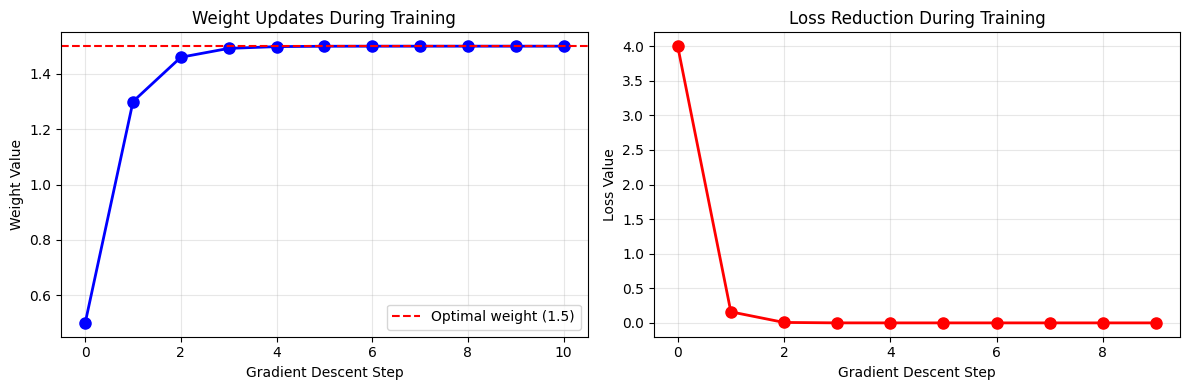


Demonstrating effect of different learning rates:


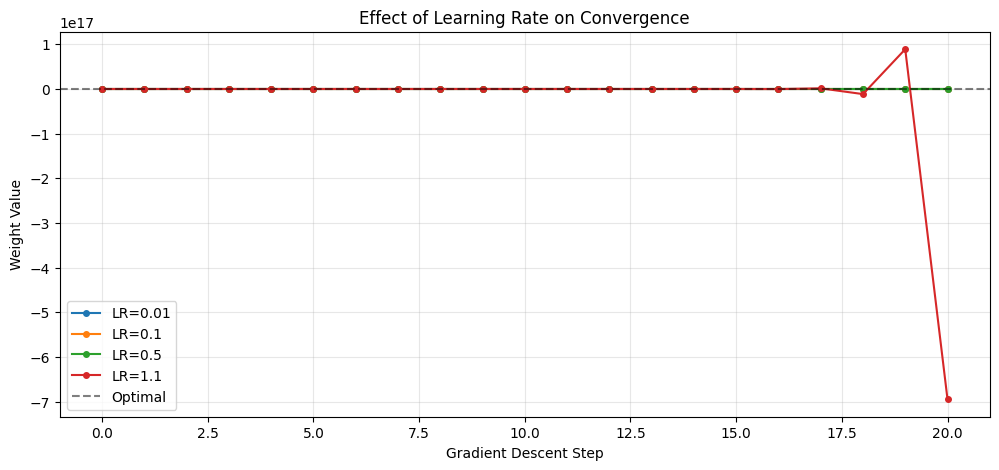

In [3]:
print("\n" + "=" * 50)
print("PART 3: GRADIENT DESCENT DEMONSTRATION")
print("=" * 50)

# Simple gradient descent with single weight
def demonstrate_single_weight_gradient_descent():
    """Show gradient descent with a single weight"""
    w = 0.5  # current weight (started randomly)
    x, y_true = 2.0, 3.0  # one training example
    learning_rate = 0.1

    print("Single Weight Gradient Descent:")
    print(f"Starting weight: {w}")
    print(f"Training example: x={x}, y_true={y_true}")

    # Store values for visualization
    weights_history = [w]
    losses_history = []

    # Perform 10 gradient descent steps
    for step in range(10):
        # Forward pass
        prediction = w * x
        loss = (prediction - y_true) ** 2

        # Backward pass (calculate gradient)
        gradient = 2 * (prediction - y_true) * x

        # Update weight
        w = w - learning_rate * gradient

        # Store history
        weights_history.append(w)
        losses_history.append(loss)

        if step < 3:  # Show first few steps in detail
            print(f"\nStep {step + 1}:")
            print(f"  Prediction: {prediction:.4f}")
            print(f"  Loss: {loss:.4f}")
            print(f"  Gradient: {gradient:.4f}")
            print(f"  Updated weight: {w:.4f}")

    return weights_history, losses_history

weights_history, losses_history = demonstrate_single_weight_gradient_descent()

# Visualize gradient descent
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot weight progression
ax1.plot(range(len(weights_history)), weights_history, 'b-o', linewidth=2, markersize=8)
ax1.set_xlabel('Gradient Descent Step')
ax1.set_ylabel('Weight Value')
ax1.set_title('Weight Updates During Training')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=1.5, color='r', linestyle='--', label='Optimal weight (1.5)')
ax1.legend()

# Plot loss progression
ax2.plot(range(len(losses_history)), losses_history, 'r-o', linewidth=2, markersize=8)
ax2.set_xlabel('Gradient Descent Step')
ax2.set_ylabel('Loss Value')
ax2.set_title('Loss Reduction During Training')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Demonstrate gradient descent with different learning rates
def gradient_descent_with_learning_rates(learning_rates):
    """Show effect of different learning rates"""
    plt.figure(figsize=(12, 5))

    for lr in learning_rates:
        w = 0.5
        weights = [w]

        for _ in range(20):
            prediction = w * 2.0
            gradient = 2 * (prediction - 3.0) * 2.0
            w = w - lr * gradient
            weights.append(w)

        plt.plot(range(len(weights)), weights, 'o-', label=f'LR={lr}', markersize=4)

    plt.axhline(y=1.5, color='k', linestyle='--', alpha=0.5, label='Optimal')
    plt.xlabel('Gradient Descent Step')
    plt.ylabel('Weight Value')
    plt.title('Effect of Learning Rate on Convergence')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("\nDemonstrating effect of different learning rates:")
gradient_descent_with_learning_rates([0.01, 0.1, 0.5, 1.1])

In [4]:
print("\n" + "=" * 50)
print("PART 4: BUILDING NEURAL NETWORK WITH KERAS")
print("=" * 50)

# Prepare Wine dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

# Standardize features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Number of classes: {len(np.unique(y_train))}")

# Build Sequential model
model = models.Sequential([
    # Input layer (13 features)
    layers.Input(shape=(13,)),

    # Hidden layer 1: 8 neurons with ReLU
    layers.Dense(8, activation='relu', name='hidden_layer_1'),

    # Hidden layer 2: 6 neurons with ReLU
    layers.Dense(6, activation='relu', name='hidden_layer_2'),

    # Output layer: 3 neurons with softmax
    layers.Dense(3, activation='softmax', name='output_layer')
])

# Display model architecture
print("\nModel Architecture:")
model.summary()

# Visualize model architecture
from tensorflow.keras.utils import plot_model
import matplotlib.image as mpimg

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',  # for integer labels
    metrics=['accuracy']
)

print("\nModel compiled successfully!")
print(f"Optimizer: Adam (learning rate: 0.01)")
print(f"Loss function: Sparse Categorical Cross-Entropy")
print(f"Metric: Accuracy")


PART 4: BUILDING NEURAL NETWORK WITH KERAS
Training set shape: (142, 13)
Test set shape: (36, 13)
Number of features: 13
Number of classes: 3

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 8)              │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187 (748.00 B)

 Trainable params: 187 (748.00 B)

 Non-trainable params: 0 (0.00 B)


Model compiled successfully!
Optimizer: Adam (learning rate: 0.01)
Loss function: Sparse Categorical Cross-Entropy
Metric: Accuracy



PART 5: TRAINING AND EVALUATION
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.4567 - loss: 1.0485 - val_accuracy: 0.4667 - val_loss: 0.9081
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6929 - loss: 0.6607 - val_accuracy: 0.6000 - val_loss: 0.7077
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7717 - loss: 0.4836 - val_accuracy: 0.6667 - val_loss: 0.5941
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8583 - loss: 0.3710 - val_accuracy: 0.8667 - val_loss: 0.5072
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9528 - loss: 0.3042 - val_accuracy: 0.9333 - val_loss: 0.4293
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9921 - loss: 0.2488 - val_accuracy: 1.0000 - val_loss: 0.3300
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9921 - loss: 0.1934 - val_accuracy: 1.0000 - val_loss: 0.2113
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9921 - loss: 0.1318 

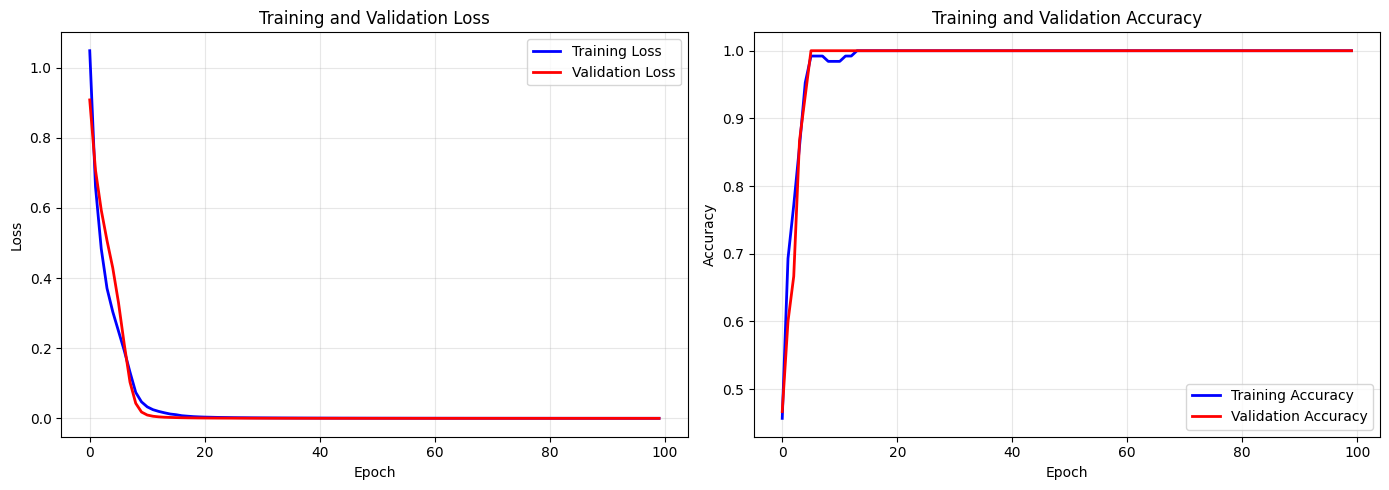


Test Performance:
Test Loss: 0.2394
Test Accuracy: 0.9444
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step

Classification Report:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



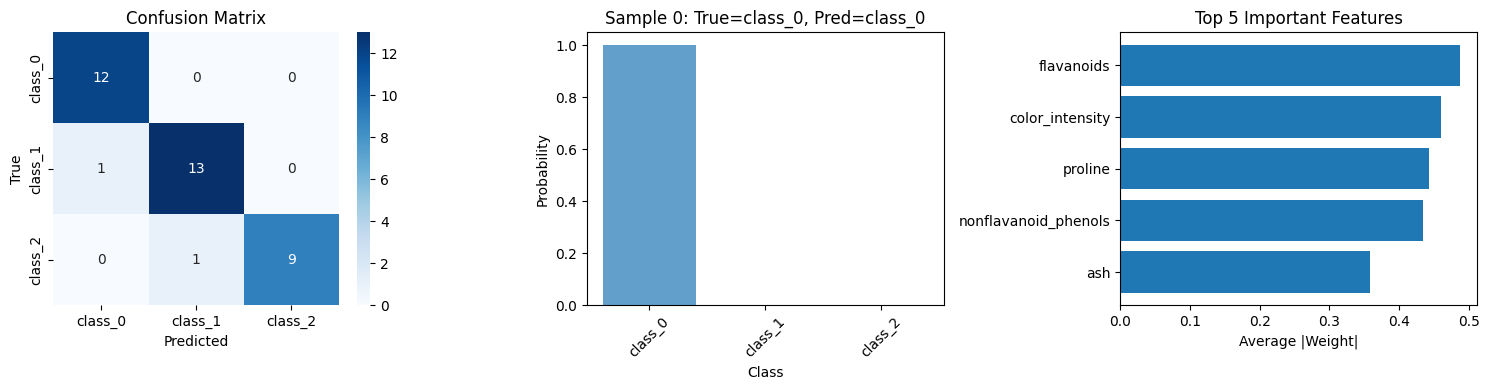


MAKING A SINGLE PREDICTION
Sample features (standardized): [-1.76503247 -0.26426092  3.23497383  2.63426892  1.30107566]...
True class: class_1
Predicted class: class_0
Prediction probabilities:
  class_0: 0.8989
  class_1: 0.1011
  class_2: 0.0000

BONUS: EXPERIMENTING WITH DIFFERENT ARCHITECTURES
Comparing different architectures:
Small (1 layer, 4 neurons): Test Accuracy = 0.9722
Medium (2 layers, 8-6 neurons): Test Accuracy = 0.9722
Large (3 layers, 16-12-8 neurons): Test Accuracy = 0.9722
Deep (4 layers, 32-16-8-4 neurons): Test Accuracy = 0.9444


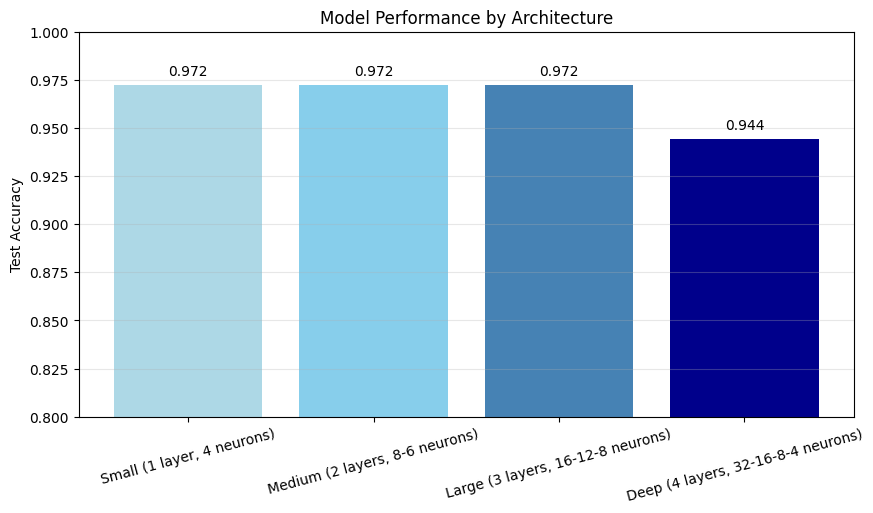


✅ Lab Complete! You've learned:
   • Neural network fundamentals
   • Single neuron computation
   • Forward propagation
   • Loss functions and gradient descent
   • Building and training models with Keras
   • Evaluating model performance


In [5]:
print("\n" + "=" * 50)
print("PART 5: TRAINING AND EVALUATION")
print("=" * 50)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,  # Process 16 samples at a time
    validation_split=0.1,  # Use 10% of training data for validation
    verbose=1  # Show progress bar
)

# Visualize training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Performance:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

# Visualize predictions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=wine.target_names, yticklabels=wine.target_names)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Show some predictions with probabilities
sample_indices = [0, 5, 10, 15, 20, 25]
for idx, sample_idx in enumerate(sample_indices[:6]):
    if sample_idx < len(X_test_scaled):
        probs = y_pred_probs[sample_idx]
        pred_class = np.argmax(probs)
        true_class = y_test[sample_idx]

        axes[1].bar(range(3), probs, alpha=0.7)
        axes[1].set_title(f'Sample {sample_idx}: True={wine.target_names[true_class]}, Pred={wine.target_names[pred_class]}')
        axes[1].set_xlabel('Class')
        axes[1].set_ylabel('Probability')
        axes[1].set_xticks(range(3))
        axes[1].set_xticklabels(wine.target_names, rotation=45)
        break

# Feature importance approximation (using weights from first layer)
first_layer_weights = model.layers[0].get_weights()[0]
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
top_features_idx = np.argsort(feature_importance)[-5:][::-1]

axes[2].barh(range(5), feature_importance[top_features_idx])
axes[2].set_yticks(range(5))
axes[2].set_yticklabels([feature_names[i] for i in top_features_idx])
axes[2].set_xlabel('Average |Weight|')
axes[2].set_title('Top 5 Important Features')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Demonstrate making a single prediction
print("\n" + "=" * 50)
print("MAKING A SINGLE PREDICTION")
print("=" * 50)

# Take one sample from test set
sample_idx = 3
sample_features = X_test_scaled[sample_idx]
sample_true_label = y_test[sample_idx]

# Make prediction
sample_pred_probs = model.predict(sample_features.reshape(1, -1), verbose=0)[0]
sample_pred_class = np.argmax(sample_pred_probs)

print(f"Sample features (standardized): {sample_features[:5]}...")
print(f"True class: {wine.target_names[sample_true_label]}")
print(f"Predicted class: {wine.target_names[sample_pred_class]}")
print(f"Prediction probabilities:")
for class_idx, class_name in enumerate(wine.target_names):
    print(f"  {class_name}: {sample_pred_probs[class_idx]:.4f}")

# Bonus: Experiment with different architectures
print("\n" + "=" * 50)
print("BONUS: EXPERIMENTING WITH DIFFERENT ARCHITECTURES")
print("=" * 50)

def create_and_train_model(hidden_layers, neurons_per_layer, learning_rate=0.01):
    """Create and train a model with specified architecture"""
    model = models.Sequential()
    model.add(layers.Input(shape=(13,)))

    # Add hidden layers
    for i in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer[i], activation='relu', name=f'hidden_{i+1}'))

    # Output layer
    model.add(layers.Dense(3, activation='softmax', name='output'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=50,
        batch_size=16,
        validation_split=0.1,
        verbose=0
    )

    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

    return test_acc, history

# Compare different architectures
architectures = [
    ([4], 'Small (1 layer, 4 neurons)'),
    ([8, 6], 'Medium (2 layers, 8-6 neurons)'),
    ([16, 12, 8], 'Large (3 layers, 16-12-8 neurons)'),
    ([32, 16, 8, 4], 'Deep (4 layers, 32-16-8-4 neurons)')
]

print("Comparing different architectures:")
results = []
for neurons, label in architectures:
    test_acc, history = create_and_train_model(len(neurons), neurons)
    results.append((label, test_acc))
    print(f"{label}: Test Accuracy = {test_acc:.4f}")

# Visualize comparison
plt.figure(figsize=(10, 5))
labels = [r[0] for r in results]
accuracies = [r[1] for r in results]
plt.bar(labels, accuracies, color=['lightblue', 'skyblue', 'steelblue', 'darkblue'])
plt.ylabel('Test Accuracy')
plt.title('Model Performance by Architecture')
plt.ylim(0.8, 1.0)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f'{acc:.3f}', ha='center')
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print("\n✅ Lab Complete! You've learned:")
print("   • Neural network fundamentals")
print("   • Single neuron computation")
print("   • Forward propagation")
print("   • Loss functions and gradient descent")
print("   • Building and training models with Keras")
print("   • Evaluating model performance")